<a href="https://colab.research.google.com/github/AISHWARYAARULSELVAN/IPCV/blob/main/Exp_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving right.png to right (10).png
Saving left.png to left (12).png

  STEREO VISION — DEPTH ESTIMATION

Loading left image : right (10).png
Loading right image: left (12).png

✓ Left  image size: (540, 720)
✓ Right image size: (315, 408)

Computing disparity with StereoSGBM …

Raw disparity range : -1.00  →  159.00
Valid pixels (>0)   : 90955
Invalid pixels (-1) : 286695

✓ WLS filter applied (opencv-contrib found)

✓ Depth post-processed  (median = 1684.2 mm)


DEPTH STATISTICS
Disparity  min / mean / max : 0.06 / 34.63 / 159.00
Depth (mm) min / mean / max : 0.0 / 2652.9 / 5052.6


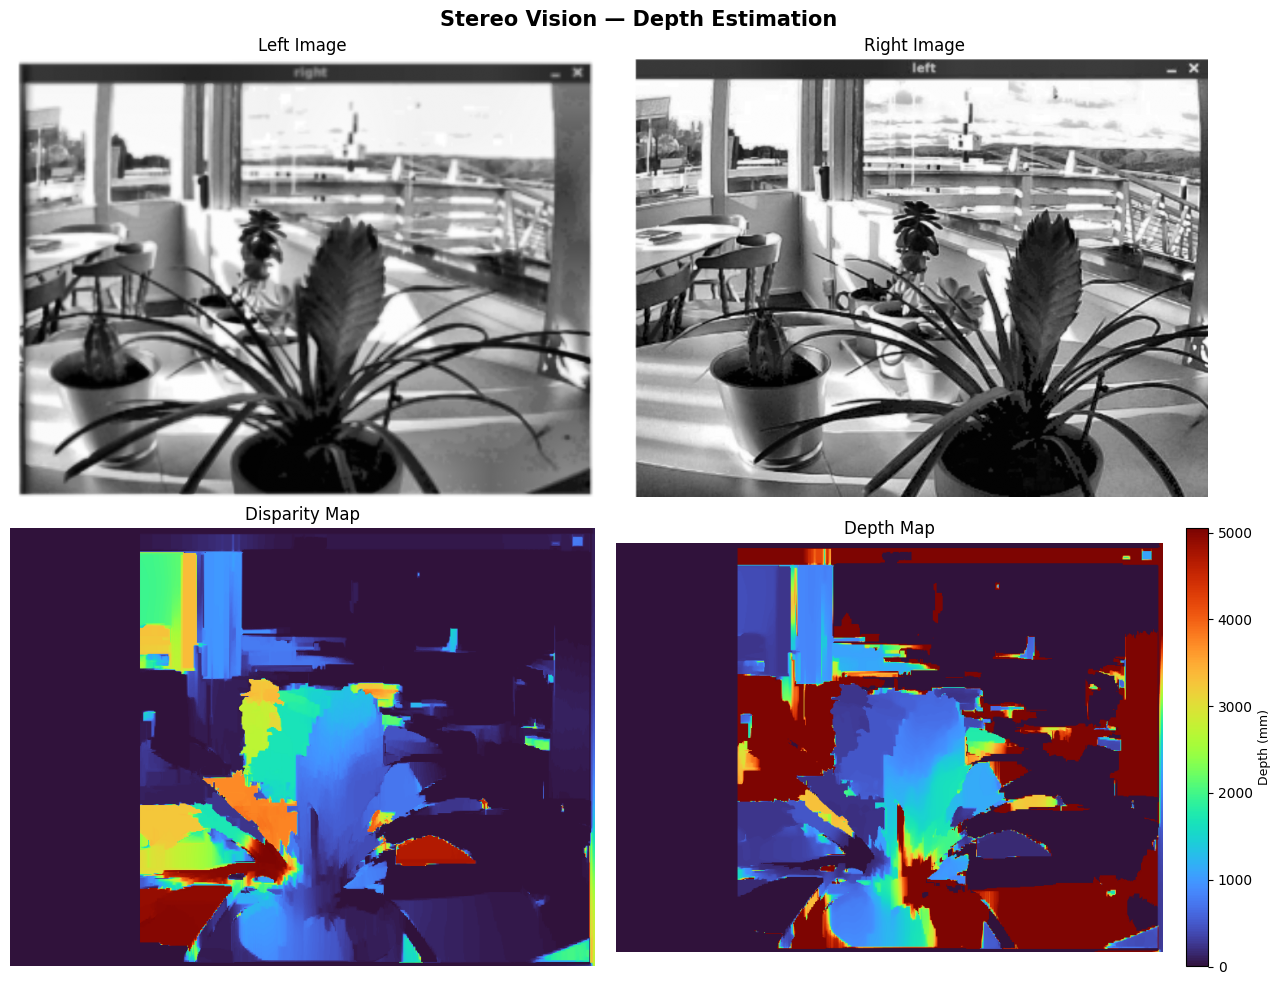

✓ Result saved as depth_result.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✓ DONE!


In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# ----------------------------
# UPLOAD IMAGES
# ----------------------------
if IN_COLAB:
    uploaded = files.upload()
    files_list = list(uploaded.keys())
    left_path = files_list[0]
    right_path = files_list[1]
else:
    # Change these paths when running locally
    left_path = "left.png"
    right_path = "right.png"


# ----------------------------
# LOAD IMAGES
# ----------------------------
def load_stereo_images(left_path, right_path):
    print(f"Loading left image : {left_path}")
    print(f"Loading right image: {right_path}\n")

    left_img  = cv2.imread(left_path,  cv2.IMREAD_GRAYSCALE)
    right_img = cv2.imread(right_path, cv2.IMREAD_GRAYSCALE)

    if left_img is None:
        print("❌ Could not load left image!")
        return None, None
    if right_img is None:
        print("❌ Could not load right image!")
        return None, None

    print(f"✓ Left  image size: {left_img.shape}")
    print(f"✓ Right image size: {right_img.shape}\n")
    return left_img, right_img


# ----------------------------
# PREPROCESS
# ----------------------------
def preprocess(left_img, right_img, max_width=800):
    """Resize if too large, then equalize histogram for better matching."""

    # Resize
    h, w = left_img.shape
    if w > max_width:
        scale = max_width / w
        left_img  = cv2.resize(left_img,  None, fx=scale, fy=scale)
        right_img = cv2.resize(right_img, None, fx=scale, fy=scale)
        print(f"Resized to: {left_img.shape}\n")

    # Match right image size to left (safety)
    if left_img.shape != right_img.shape:
        right_img = cv2.resize(right_img, (left_img.shape[1], left_img.shape[0]))

    # CLAHE equalisation — improves texture, helps matcher
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    left_img  = clahe.apply(left_img)
    right_img = clahe.apply(right_img)

    return left_img, right_img


# ----------------------------
# DISPARITY COMPUTATION
# ----------------------------
def compute_disparity(left_img, right_img):
    """
    Uses StereoSGBM (much better than StereoBM on real images).
    Falls back to WLS filtering if opencv-contrib is available.
    """
    print("Computing disparity with StereoSGBM …\n")

    window_size    = 5
    num_disp       = 16 * 10   # increase to 16*12 or 16*16 if objects are very close

    stereo = cv2.StereoSGBM_create(
        minDisparity     = 0,
        numDisparities   = num_disp,
        blockSize        = window_size,
        P1               = 8  * 3 * window_size ** 2,
        P2               = 32 * 3 * window_size ** 2,
        disp12MaxDiff    = 1,
        uniquenessRatio  = 10,
        speckleWindowSize= 100,
        speckleRange     = 32,
        preFilterCap     = 63,
        mode             = cv2.STEREO_SGBM_MODE_SGBM_3WAY
    )

    disparity_raw = stereo.compute(left_img, right_img)

    # ---- Diagnostic ----
    disp_f = np.float32(disparity_raw) / 16.0
    print(f"Raw disparity range : {disp_f.min():.2f}  →  {disp_f.max():.2f}")
    print(f"Valid pixels (>0)   : {np.sum(disp_f > 0)}")
    print(f"Invalid pixels (-1) : {np.sum(disp_f < 0)}\n")

    # ---- Try WLS filter (needs opencv-contrib) ----
    try:
        right_matcher = cv2.ximgproc.createRightMatcher(stereo)
        disp_right    = right_matcher.compute(right_img, left_img)

        wls = cv2.ximgproc.createDisparityWLSFilter(stereo)
        wls.setLambda(8000)
        wls.setSigmaColor(1.5)
        disp_filtered = wls.filter(disparity_raw, left_img,
                                    disparity_map_right=disp_right)

        disparity = np.float32(disp_filtered) / 16.0
        print("✓ WLS filter applied (opencv-contrib found)\n")

    except AttributeError:
        print("ℹ  opencv-contrib not found — skipping WLS filter.")
        print("   Install with: pip install opencv-contrib-python\n")
        disparity = disp_f

    # Clamp negatives (invalid markers) to 0
    disparity = np.clip(disparity, 0, None)

    return disparity


# ----------------------------
# DEPTH MAP
# ----------------------------
def disparity_to_depth(disparity, baseline_mm=65.0, focal_px=400.0):
    """Convert disparity → depth.  depth = (B * f) / d"""
    with np.errstate(divide='ignore', invalid='ignore'):
        depth = np.where(disparity > 0,
                         (baseline_mm * focal_px) / disparity,
                         0.0)
    return depth.astype(np.float32)


# ----------------------------
# POST-PROCESS DEPTH
# ----------------------------
def postprocess_depth(depth):
    valid = depth[depth > 0]
    if len(valid) == 0:
        print("⚠  No valid depth values found!")
        return depth

    median_d = np.median(valid)
    lo, hi   = median_d * 0.1, median_d * 3.0

    depth = np.clip(depth, 0, hi)
    depth[depth < lo] = 0

    # Bilateral filter — edge-preserving smoothing
    depth = cv2.bilateralFilter(depth, d=9, sigmaColor=75, sigmaSpace=75)

    print(f"✓ Depth post-processed  (median = {median_d:.1f} mm)\n")
    return depth


# ----------------------------
# STATISTICS
# ----------------------------
def print_statistics(disparity, depth):
    print("\n" + "=" * 60)
    print("DEPTH STATISTICS")
    print("=" * 60)

    valid_d = disparity[disparity > 0]
    valid_z = depth[depth > 0]

    if len(valid_d):
        print(f"Disparity  min / mean / max : "
              f"{valid_d.min():.2f} / {valid_d.mean():.2f} / {valid_d.max():.2f}")
    else:
        print("No valid disparity values.")

    if len(valid_z):
        print(f"Depth (mm) min / mean / max : "
              f"{valid_z.min():.1f} / {valid_z.mean():.1f} / {valid_z.max():.1f}")
    else:
        print("No valid depth values.")

    print("=" * 60)


# ----------------------------
# VISUALISATION
# ----------------------------
def visualize(left_img, right_img, disparity, depth):

    def to_u8(arr):
        """Normalise float array to uint8, ignoring zeros for scale."""
        mask = arr > 0
        out  = np.zeros_like(arr, dtype=np.uint8)
        if mask.any():
            lo, hi = arr[mask].min(), arr[mask].max()
            if hi > lo:
                out[mask] = ((arr[mask] - lo) / (hi - lo) * 255).astype(np.uint8)
        return out

    disp_u8  = to_u8(disparity)
    depth_u8 = to_u8(depth)

    # Apply a perceptually uniform colormap (TURBO looks great for depth)
    disp_color  = cv2.applyColorMap(disp_u8,  cv2.COLORMAP_TURBO)
    depth_color = cv2.applyColorMap(depth_u8, cv2.COLORMAP_TURBO)

    fig, axes = plt.subplots(2, 2, figsize=(13, 10))
    fig.suptitle("Stereo Vision — Depth Estimation", fontsize=15, fontweight='bold')

    axes[0, 0].imshow(left_img,  cmap='gray')
    axes[0, 0].set_title("Left Image");  axes[0, 0].axis("off")

    axes[0, 1].imshow(right_img, cmap='gray')
    axes[0, 1].set_title("Right Image"); axes[0, 1].axis("off")

    axes[1, 0].imshow(cv2.cvtColor(disp_color,  cv2.COLOR_BGR2RGB))
    axes[1, 0].set_title("Disparity Map"); axes[1, 0].axis("off")

    im = axes[1, 1].imshow(cv2.cvtColor(depth_color, cv2.COLOR_BGR2RGB))
    axes[1, 1].set_title("Depth Map"); axes[1, 1].axis("off")

    # Colorbar for depth
    valid_z = depth[depth > 0]
    if len(valid_z):
        sm = plt.cm.ScalarMappable(
            cmap='turbo',
            norm=plt.Normalize(vmin=valid_z.min(), vmax=valid_z.max())
        )
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=axes[1, 1], fraction=0.046, pad=0.04)
        cbar.set_label("Depth (mm)", fontsize=9)

    plt.tight_layout()
    plt.savefig("depth_result.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Result saved as depth_result.png")

    # Download in Colab
    if IN_COLAB:
        files.download("depth_result.png")


# ----------------------------
# MAIN
# ----------------------------
def main():
    print("\n" + "=" * 60)
    print("  STEREO VISION — DEPTH ESTIMATION")
    print("=" * 60 + "\n")

    # 1. Load
    left_img, right_img = load_stereo_images(left_path, right_path)
    if left_img is None:
        return

    # 2. Preprocess (resize + CLAHE)
    left_img, right_img = preprocess(left_img, right_img)

    # 3. Disparity
    disparity = compute_disparity(left_img, right_img)

    # 4. Depth
    depth = disparity_to_depth(disparity)

    # 5. Post-process
    depth = postprocess_depth(depth)

    # 6. Stats
    print_statistics(disparity, depth)

    # 7. Visualise
    visualize(left_img, right_img, disparity, depth)

    print("\n✓ DONE!")


if __name__ == "__main__":
    main()